LIBRARIES

In [33]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.optim as optim
import matplotlib.pyplot as plt

INPUTS

In [34]:
#Variables:
batch_size = 64
img_size = 28
patch_size = 7
num_channels =1
num_layers= 7
num_heads= 7
num_classes =10
embed_dim = 49
num_patches = (img_size//patch_size)**2
mlp_nodes = 4*embed_dim
epochs =10
learning_rate = 0.001

In [35]:
transform = transforms.Compose([
    transforms.ToTensor()
])
train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
val_data = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_dataset = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_dataset = DataLoader(val_data, batch_size=batch_size, shuffle=True)

NETWORK ARCHITECTURE

In [36]:
#ViT Architecture ==> 1. class for Patch Embedding
class PatchEmbedding(nn.Module):
  def __init__(self):
    super().__init__()
    self.patch_embed = nn.Conv2d(num_channels, embed_dim, kernel_size = patch_size, stride=patch_size)

  def forward(self, x):
    x = self.patch_embed(x)
    x = x.flatten(2).transpose(1,2)
    return x



In [37]:
#ViT Architecture ==> 2. Class for Transformer Block
class TransformerEncoder(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_norm1 = nn.LayerNorm(embed_dim)
    self.layer_norm2 = nn.LayerNorm(embed_dim)
    self.attention = nn.MultiheadAttention(embed_dim, num_heads, batch_first=True)
    self.mlp = nn.Sequential(
        nn.Linear(embed_dim, mlp_nodes),
        nn.GELU(),
        nn.Linear(mlp_nodes, embed_dim)
    )

  def forward(self, x):
    residual1 =x
    x = self.layer_norm1(x)
    x = self.attention(x, x, x)[0] + residual1
    residual2 = x
    x = self.layer_norm2(x)
    x = self.mlp(x) + residual2
    return x

In [38]:
#ViT Architecture ==> 3. Class for MLP Head
class MLP_Head(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_norm3 = nn.LayerNorm(embed_dim)
    self.mlp_head = nn.Sequential(
        nn.Linear(embed_dim, num_classes)
    )

  def forward(self, x):
    x = self.layer_norm3(x)
    x = self.mlp_head(x)
    return x

In [39]:
class ViT(nn.Module):
  def __init__(self):
    super().__init__()
    self.patch_embed = PatchEmbedding()
    self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))
    self.postition_embed = nn.Parameter(torch.randn(1, num_patches+1, embed_dim))
    self.transformer_blocks = nn.Sequential(*[TransformerEncoder() for _ in range(num_layers)])
    self.mlp_head = MLP_Head()

  def forward(self, x):
    x = self.patch_embed(x)
    B = x.shape[0]
    cls_tokens = self.cls_token.expand(B, -1, -1)
    x= torch.cat((cls_tokens, x), dim=1)
    x = x+ self.postition_embed
    x = self.transformer_blocks(x)
    x = x[:, 0]
    x = self.mlp_head(x)
    return x

TRAINING

In [40]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ViT().to(device)
optimizer = optim.Adam(model.parameters(), lr = learning_rate)
criterion = nn.CrossEntropyLoss()

In [41]:
def train_model(model, train_loader, val_loader, optimizer, criterion, epochs):
  train_loss =[]
  train_acc = []
  val_loss = []
  val_acc =[]
  for epoch in range(epochs):
    model.train()
    correct_preds = 0
    total_loss =0
    total_samples= 0
    for images, labels in train_loader:
      images, labels = images.to(device), labels.to(device)
      optimizer.zero_grad()
      outputs =model(images)
      loss = criterion(outputs, labels)
      loss.backward()
      optimizer.step()

      predictions = outputs.argmax(dim =1)
      correct_preds += (predictions == labels).sum().item()
      total_loss+= loss.item()
      total_samples += predictions.size(0)

    acc = correct_preds/total_samples
    train_loss.append(total_loss)
    train_acc.append(acc)
    print(f"Epoch {epoch+1}: Train Loss: {total_loss:.4f}, Accuracy: {acc:.4f}")

    model.eval()
    with torch.no_grad():
      eval_preds = 0
      eval_loss = 0
      eval_samples =0
      for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)
        predictions = outputs.argmax(dim=1)
        eval_preds += (predictions == labels).sum().item()
        eval_loss += loss.item()
        eval_samples += predictions.size(0)

      eval_acc = eval_preds/eval_samples
      val_loss.append(eval_loss)
      val_acc.append(eval_acc)
      print(f"Validation Loss: {eval_loss:.4f}, Validation Accuracy: {eval_acc:.4f}")

  return train_loss, train_acc, val_loss, val_acc


In [42]:
train_loss, train_acc, val_loss, val_acc = train_model(model, train_dataset, val_dataset, optimizer, criterion, epochs)

Epoch 1: Train Loss: 408.0754, Accuracy: 0.8570
Validation Loss: 25.4167, Validation Accuracy: 0.9510
Epoch 2: Train Loss: 118.6905, Accuracy: 0.9616
Validation Loss: 18.2211, Validation Accuracy: 0.9657
Epoch 3: Train Loss: 83.5490, Accuracy: 0.9725
Validation Loss: 15.8628, Validation Accuracy: 0.9683
Epoch 4: Train Loss: 67.7360, Accuracy: 0.9768
Validation Loss: 12.0977, Validation Accuracy: 0.9760
Epoch 5: Train Loss: 54.1150, Accuracy: 0.9819
Validation Loss: 10.7512, Validation Accuracy: 0.9781
Epoch 6: Train Loss: 47.9637, Accuracy: 0.9837
Validation Loss: 11.6582, Validation Accuracy: 0.9773
Epoch 7: Train Loss: 42.7333, Accuracy: 0.9848
Validation Loss: 11.5614, Validation Accuracy: 0.9787
Epoch 8: Train Loss: 38.3739, Accuracy: 0.9864
Validation Loss: 10.1696, Validation Accuracy: 0.9808
Epoch 9: Train Loss: 32.7987, Accuracy: 0.9884
Validation Loss: 10.8741, Validation Accuracy: 0.9793
Epoch 10: Train Loss: 29.6782, Accuracy: 0.9898
Validation Loss: 9.6314, Validation Accur

PLOTTING

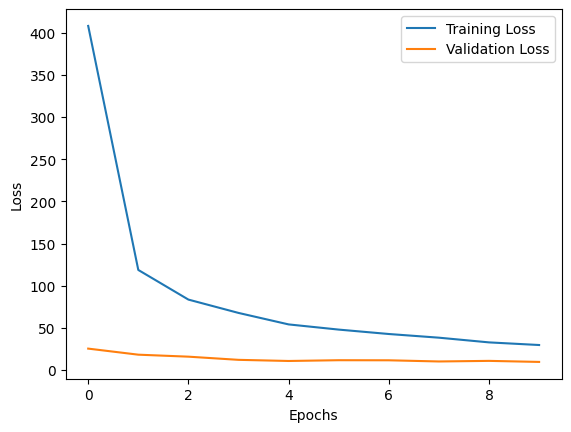

In [43]:
plt.plot(train_loss, label = "Training Loss")
plt.plot(val_loss, label = "Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

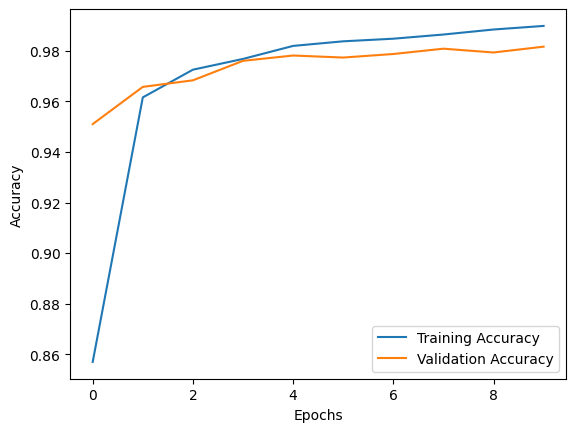

In [44]:
plt.plot(train_acc, label = "Training Accuracy")
plt.plot(val_acc, label = "Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()